# linear_dynamics plot (Julia + CairoMakie)
保存済み `summary.csv` を読み込み、`N, M` ごとの mean ± SE を描画します。

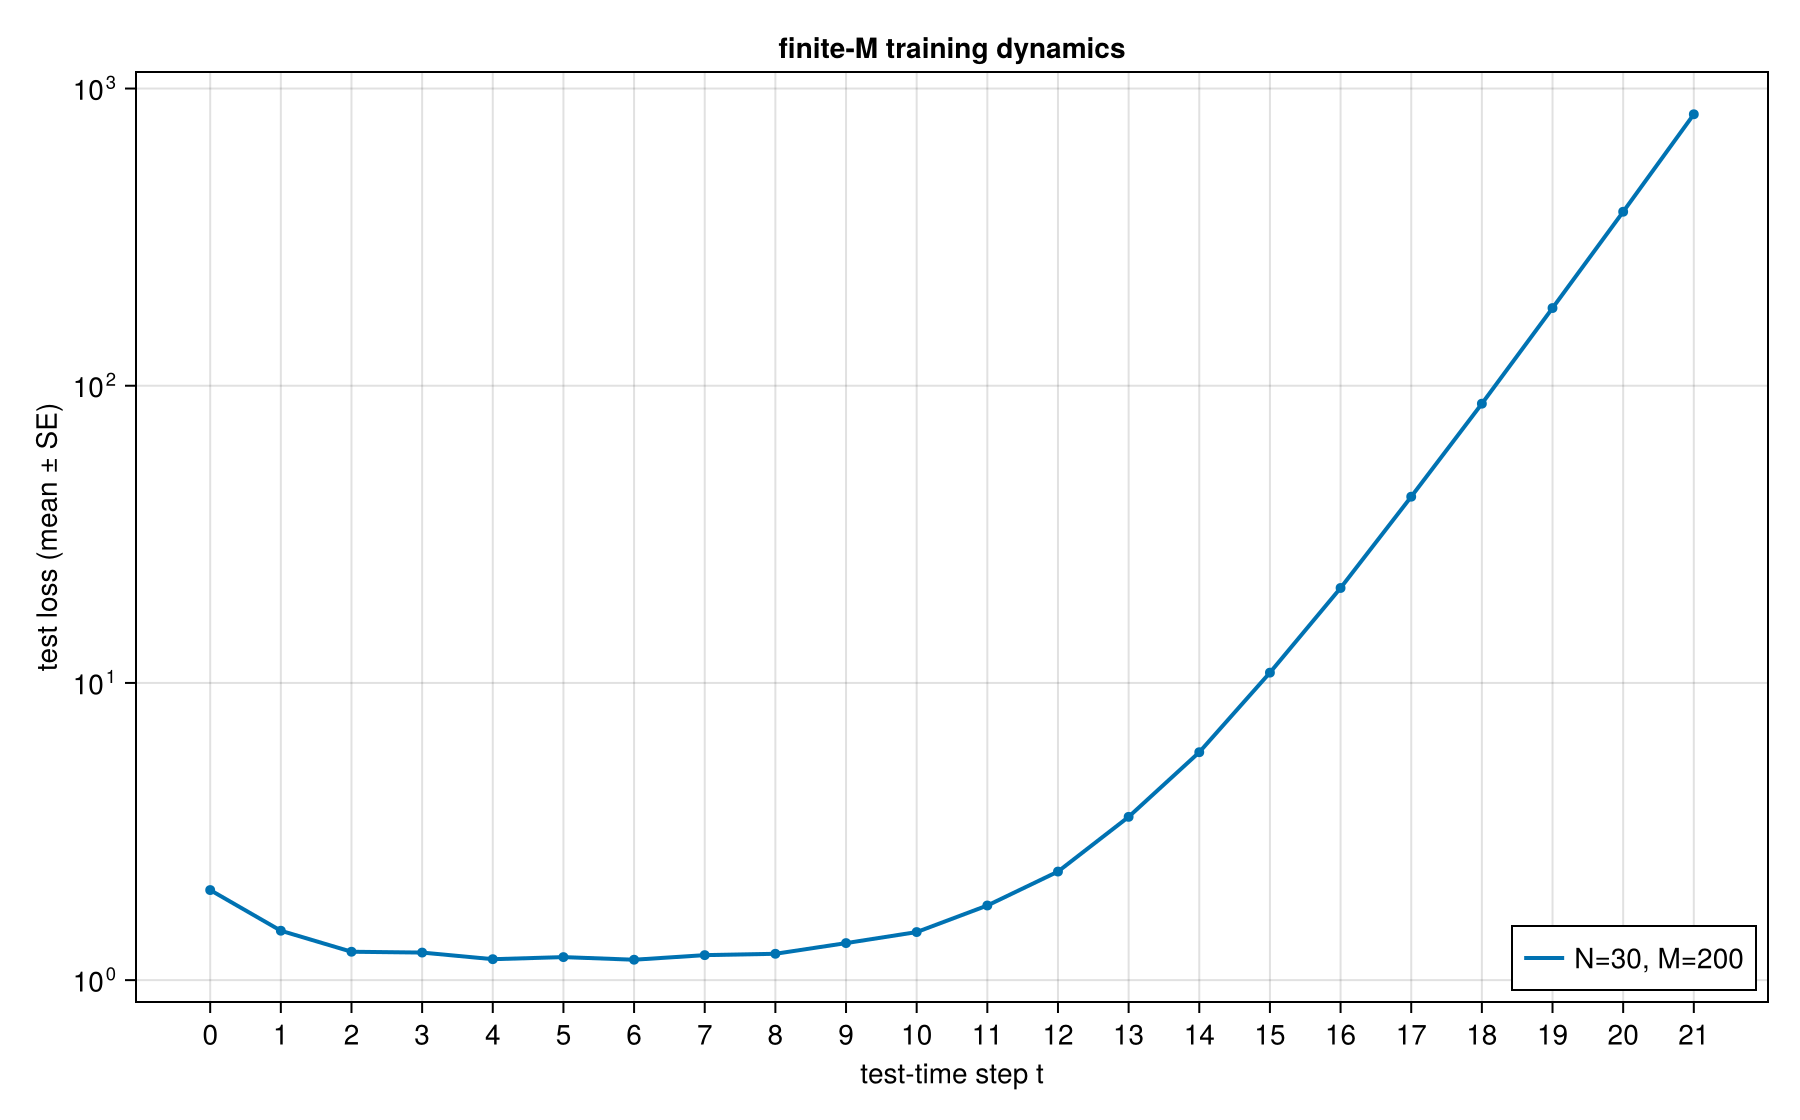

In [2]:
using CairoMakie
using CSV
using DataFrames

base_dir = "/home/takanami/cot_asymptotics/linear_dynamics"
results_root = joinpath(base_dir, "results")
dirs = filter(d -> startswith(d, "linear_dynamics_"), readdir(results_root))
isempty(dirs) && error("No results directory found in: $(results_root)")
latest_dir = joinpath(results_root, sort(dirs)[end])

df = CSV.read(joinpath(latest_dir, "summary.csv"), DataFrame)

pairs = sort(unique(select(df, [:n, :m])))
fig = Figure(size = (900, 560))
ax = Axis(
    fig[1, 1],
    xlabel = "test-time step t",
    ylabel = "test loss (mean ± SE)",
    title = "finite-M training dynamics",
    yscale = log10,
)

colors = Makie.wong_colors()
for (k, row) in enumerate(eachrow(pairs))
    sub = sort(df[(df.n .== row.n) .& (df.m .== row.m), :], :t)
    t = Float64.(sub.t)
    meanv = Float64.(sub.mean_loss)
    sev = Float64.(sub.se_loss)
    lower = max.(meanv .- sev, eps(Float64))
    upper = meanv .+ sev
    c = colors[mod1(k, length(colors))]

    band!(ax, t, lower, upper, color = (c, 0.18))
    lines!(ax, t, meanv, color = c, linewidth = 2, label = "N=$(row.n), M=$(row.m)")
    scatter!(ax, t, meanv, color = c, markersize = 7)
end

ax.xticks = sort(unique(Int.(df.t)))
axislegend(ax, position = :rb)
fig